# TradeCoach

## 설계서 요약

### 01 LangGraph 노드 설계서 (v1.2)

| 레이어 | 노드 | 역할 |
|--------|------|------|
| 입력 | `memory_load_node` | DB에서 과거 약점/통계 로드 |
| 입력 | `input_router_node` | CSV / 이미지 / 혼합 입력 판별 |
| 분석 | `journal_analysis_node` | 통계 산출 (승률, 손익비, 드로다운) |
| 분석 | `weakness_detect_node` | 반복 실수 패턴 추출 |
| 분석 | `chart_analysis_node` | Claude Vision ICT 차트 분석 |
| 피드백 | `feedback_node` | 매수·매도 근거 피드백 생성 |
| 학습 | `lesson_gen_node` | 약점 기반 커리큘럼 생성 |
| 학습 | `quiz_node` | 개념 퀴즈 출제 |
| 학습 | `reinforce_node` | 오답 시 개념 보강 |
| 저장 | `memory_save_node` | 분석 결과 DB 저장 |

**라우팅 규칙**
- `input_router` → `journal_analysis` (journal only)
- `input_router` → `chart_analysis` (chart only)
- `input_router` → `journal_analysis` + `chart_analysis` (both)
- `quiz_node` pass → `memory_save` / fail & retry < 3 → `reinforce` / retry ≥ 3 → `memory_save`

### 04 API 명세서 (v1.2)

| 항목 | 값 |
|------|----|
| State 타입 | `TradeCoachState` (TypedDict) |
| DB | SQLite `tradecoach.db` (`db.py` 참조) |
| LLM 모델 | `claude-sonnet-4-6` (텍스트 + Vision 공용) |
| 노드 시그니처 | `(state: TradeCoachState) -> dict` |

---
**Step 2 구현 범위:** `TradeCoachState` · `memory_load_node` · `input_router_node` · 기본 그래프 연결

In [22]:
import os
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END

from db import get_db, init_db

load_dotenv()

MODEL = "openai:gpt-4o"

init_db()
print("DB initialized")

DB initialized


## TradeCoachState

API 명세서 §2 기준 전체 필드. 노드는 변경할 키만 `dict`로 반환합니다.

In [23]:
class TradeCoachState(TypedDict, total=False):
    session_id:      str
    input_type:      str          # 'journal' | 'chart' | 'both'
    journal_data:    str          # CSV 원문
    chart_image:     str          # base64 인코딩 이미지
    stats:           dict         # 승률/손익비/드로다운 등
    weaknesses:      list         # 현재 세션 약점 태그
    past_weaknesses: list         # DB 로드 과거 약점
    chart_feedback:  str          # 차트 분석 결과 텍스트
    current_concept: str          # 현재 학습 중인 개념
    quiz_question:   str          # 퀴즈 문항
    quiz_answer:     str          # 사용자 답변
    quiz_result:     str          # 'pass' | 'fail' | ''
    retry_count:     int          # 퀴즈 재시도 횟수
    trade_count:     int          # 총 분석 트레이드 수
    improvement_log: list         # 세션별 실력 변화
    messages:        list         # 대화 히스토리


DEFAULT_STATE: TradeCoachState = {
    "session_id":      "default",
    "input_type":      "",
    "journal_data":    "",
    "chart_image":     "",
    "stats":           {},
    "weaknesses":      [],
    "past_weaknesses": [],
    "chart_feedback":  "",
    "current_concept": "",
    "quiz_question":   "",
    "quiz_answer":     "",
    "quiz_result":     "",
    "retry_count":     0,
    "trade_count":     0,
    "improvement_log": [],
    "messages":        [],
}

## memory_load_node

**역할:** 세션 시작 시 SQLite에서 과거 데이터 로드  
**입력:** `session_id`  
**출력:** `past_weaknesses`, `trade_count`, `improvement_log`  
**부수효과:** 없음 (읽기 전용). DB 없거나 오류 시 빈 값 반환.

In [24]:
def memory_load_node(state: TradeCoachState) -> dict:
    session_id = state.get("session_id", "default")
    past_weaknesses = []
    trade_count = 0
    improvement_log = []

    try:
        with get_db() as conn:
            rows = conn.execute(
                "SELECT weakness FROM weaknesses WHERE session_id = ? ORDER BY count DESC",
                (session_id,),
            ).fetchall()
            past_weaknesses = [r["weakness"] for r in rows]

            count_row = conn.execute(
                "SELECT COALESCE(SUM(trade_count), 0) FROM trade_history WHERE session_id = ?",
                (session_id,),
            ).fetchone()
            trade_count = int(count_row[0]) if count_row else 0

            history_rows = conn.execute(
                "SELECT date, win_rate, avg_rr FROM trade_history"
                " WHERE session_id = ? ORDER BY date DESC LIMIT 10",
                (session_id,),
            ).fetchall()
            improvement_log = [dict(r) for r in history_rows]
    except Exception:
        pass

    return {
        "past_weaknesses": past_weaknesses,
        "trade_count":     trade_count,
        "improvement_log": improvement_log,
    }

## input_router_node

**역할:** 입력 타입 판별 후 `input_type` 설정  

| journal_data | chart_image | input_type |
|:---:|:---:|:---:|
| ✓ | ✗ | `'journal'` |
| ✗ | ✓ | `'chart'` |
| ✓ | ✓ | `'both'` |
| ✗ | ✗ | `'journal'` (기본값) |

In [25]:
def input_router_node(state: TradeCoachState) -> dict:
    has_journal = bool(state.get("journal_data", "").strip())
    has_chart   = bool(state.get("chart_image",  "").strip())

    if has_journal and has_chart:
        input_type = "both"
    elif has_chart:
        input_type = "chart"
    else:
        input_type = "journal"

    return {"input_type": input_type}


def route_after_input(state: TradeCoachState) -> str:
    return state["input_type"]

## 그래프 연결

```
START → memory_load → input_router → (journal/chart/both) → END
```

Step 3+에서 `END` 스텁을 `journal_analysis_node`, `chart_analysis_node`로 교체 예정.

In [26]:
builder = StateGraph(TradeCoachState)

builder.add_node("memory_load",  memory_load_node)
builder.add_node("input_router", input_router_node)

builder.add_edge(START, "memory_load")
builder.add_edge("memory_load", "input_router")
builder.add_conditional_edges(
    "input_router",
    route_after_input,
    {
        "journal": END,
        "chart":   END,
        "both":    END,
    },
)

graph = builder.compile()
print("Graph compiled")

Graph compiled


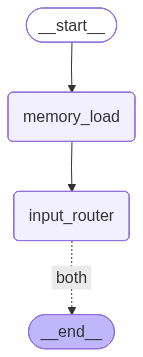

In [27]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## 동작 테스트

In [28]:
test_cases = [
    {"label": "journal only", "journal_data": "date,result\n2026-05-01,win", "chart_image": ""},
    {"label": "chart only",   "journal_data": "",                            "chart_image": "base64data=="},
    {"label": "both inputs",  "journal_data": "date,result\n2026-05-01,win", "chart_image": "base64data=="},
    {"label": "empty input",  "journal_data": "",                            "chart_image": ""},
]

for tc in test_cases:
    state = {**DEFAULT_STATE, "session_id": "test_user",
             "journal_data": tc["journal_data"], "chart_image": tc["chart_image"]}
    result = graph.invoke(state)
    print(f"[{tc['label']:13s}] input_type={result['input_type']!r:10s}"
          f" past_weaknesses={result['past_weaknesses']}"
          f" trade_count={result['trade_count']}")

[journal only ] input_type='journal'  past_weaknesses=[] trade_count=0
[chart only   ] input_type='chart'    past_weaknesses=[] trade_count=0
[both inputs  ] input_type='both'     past_weaknesses=[] trade_count=0
[empty input  ] input_type='journal'  past_weaknesses=[] trade_count=0


---
# Step 3: journal_analysis_node · weakness_detect_node

| 노드 | 역할 | LLM |
|------|------|-----|
| `journal_analysis_node` | CSV → stats (win_rate / avg_rr / max_drawdown / best·worst_setup) | OpenAI `gpt-4o-mini` |
| `weakness_detect_node` | stats + past_weaknesses → weakness 태그 리스트 | 없음 (임계값 규칙 기반) |

**임계값 규칙 (노드 설계서 §3.3)**

| 지표 | 임계값 | 약점 태그 |
|------|--------|----------|
| win_rate | < 0.4 | `승률_낮음` |
| avg_rr | < 1.5 | `손익비_부족` |
| max_drawdown | ≥ 3 | `연속손실_패턴` |
| worst_setup | 존재 시 | `{setup명}_개선필요` |

**그래프 변경:** `input_router → journal_analysis → weakness_detect → END`  
(`chart` 경로는 Step 4에서 `chart_analysis_node` 연결 예정)

In [29]:
from nodes.analysis_nodes import journal_analysis_node, weakness_detect_node

### 그래프 재구성

```
START
  └─ memory_load
       └─ input_router
            ├─ journal ──┐
            ├─ both ─────┤
            │            ▼
            │    journal_analysis
            │            └─ weakness_detect → END
            └─ chart ──→ END  (Step 4 예정)
```

In [30]:
builder = StateGraph(TradeCoachState)

builder.add_node("memory_load",      memory_load_node)
builder.add_node("input_router",     input_router_node)
builder.add_node("journal_analysis", journal_analysis_node)
builder.add_node("weakness_detect",  weakness_detect_node)

builder.add_edge(START, "memory_load")
builder.add_edge("memory_load", "input_router")
builder.add_conditional_edges(
    "input_router",
    route_after_input,
    {
        "journal": "journal_analysis",
        "both":    "journal_analysis",  # chart_analysis_node - Step 4
        "chart":   END,                 # chart_analysis_node - Step 4
    },
)
builder.add_edge("journal_analysis", "weakness_detect")
builder.add_edge("weakness_detect",  END)

graph = builder.compile()
print("Graph compiled")

Graph compiled


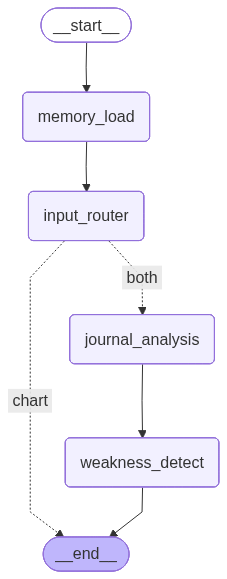

In [31]:
Image(graph.get_graph().draw_mermaid_png())

### 동작 테스트

> `OPENAI_API_KEY` 필요. `journal_analysis_node`가 OpenAI를 호출합니다.

In [32]:
test_journal = """date,setup,result,rr
2026-05-01,FVG,win,2.1
2026-05-02,FVG,loss,-1.0
2026-05-03,OrderBlock,win,1.8
2026-05-04,OrderBlock,loss,-1.0
2026-05-05,FVG,loss,-1.0
2026-05-06,FVG,loss,-1.0"""

result = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "test_user",
    "journal_data": test_journal,
})

print("stats:      ", result["stats"])
print("weaknesses: ", result["weaknesses"])
print("input_type: ", result["input_type"])

stats:       {'win_rate': 0.3333333333333333, 'avg_rr': 1.6333333333333333, 'max_drawdown': 4, 'best_setup': 'FVG', 'worst_setup': 'OrderBlock', 'trade_count': 6}
weaknesses:  ['승률_낮음', '연속손실_패턴', 'OrderBlock_개선필요']
input_type:  journal


---
# Step 4: chart_analysis_node · feedback_node

| 노드 | 역할 | LLM |
|------|------|-----|
| `chart_analysis_node` | base64 이미지 → OpenAI Vision → ICT 근거 분석 | `gpt-4o` (Vision) |
| `feedback_node` | 분석 결과 구조화 → weakness 병합 | `gpt-4o-mini` |

**그래프 변경 (Step 3 → Step 4)**

```
journal → journal_analysis → weakness_detect → END
chart   → chart_analysis   → feedback        → END
both    → journal_analysis → weakness_detect → chart_analysis → feedback → END
```

In [ ]:
from nodes.chart_nodes import chart_analysis_node, feedback_node

In [ ]:
def route_after_weakness(state: TradeCoachState) -> str:
    """both 경로: weakness_detect 후 chart_analysis로 진행."""
    return "chart_analysis" if state.get("input_type") == "both" else END


builder = StateGraph(TradeCoachState)

builder.add_node("memory_load",      memory_load_node)
builder.add_node("input_router",     input_router_node)
builder.add_node("journal_analysis", journal_analysis_node)
builder.add_node("weakness_detect",  weakness_detect_node)
builder.add_node("chart_analysis",   chart_analysis_node)
builder.add_node("feedback",         feedback_node)

builder.add_edge(START, "memory_load")
builder.add_edge("memory_load", "input_router")
builder.add_conditional_edges(
    "input_router",
    route_after_input,
    {
        "journal": "journal_analysis",
        "both":    "journal_analysis",
        "chart":   "chart_analysis",
    },
)
builder.add_edge("journal_analysis", "weakness_detect")
builder.add_conditional_edges(
    "weakness_detect",
    route_after_weakness,
    {
        "chart_analysis": "chart_analysis",
        END:              END,
    },
)
builder.add_edge("chart_analysis", "feedback")
builder.add_edge("feedback", END)

graph = builder.compile()
print("Graph compiled")

In [ ]:
Image(graph.get_graph().draw_mermaid_png())

### 동작 테스트

**journal 경로** — journal_analysis + weakness_detect 실행 (OpenAI `gpt-4o-mini` 호출)  
**chart 경로** — chart_analysis + feedback 실행 (OpenAI Vision `gpt-4o` 호출, 실제 base64 이미지 필요)  
**both 경로** — 전체 파이프라인 순차 실행

In [ ]:
# journal 경로: Step 3과 동일하게 동작 검증
result_j = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "test_user",
    "journal_data": test_journal,
})
print("[journal] input_type :", result_j["input_type"])
print("[journal] stats      :", result_j["stats"])
print("[journal] weaknesses :", result_j["weaknesses"])
print("[journal] chart_feedback:", repr(result_j.get("chart_feedback", "")))

In [ ]:
# chart 경로: 실제 이미지 base64로 교체하면 Vision 분석 실행
# import base64, pathlib
# chart_b64 = base64.b64encode(pathlib.Path("chart.png").read_bytes()).decode()

# 아래는 빈 이미지로 라우팅 경로만 확인 (chart_feedback = "")
result_c = graph.invoke({
    **DEFAULT_STATE,
    "session_id":  "test_user",
    "chart_image": "",          # ← 실제 base64로 교체
})
print("[chart] input_type   :", result_c["input_type"])
print("[chart] chart_feedback:", repr(result_c.get("chart_feedback", ""))[:80])
print("[chart] weaknesses   :", result_c.get("weaknesses", []))

---
# Step 5: search_ict_concept 테스트

`tools/concept_tool.py`의 `search_ict_concept` 도구를 직접 호출해
각 weakness 태그별 조회 결과 및 fallback 동작을 확인합니다.

In [ ]:
from tools.concept_tool import search_ict_concept

# 정의된 weakness 태그 전체 조회
tags = [
    "FVG",
    "OrderBlock",
    "BreakerBlock",
    "유동성스윕",
    "BOS",
    "CHoCH",
    "OTE",
    "프리미엄_디스카운트",
    "손익비_부족",
    "연속손실_패턴",
    "승률_낮음",
]

for tag in tags:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    print(result)
    print("-" * 60)

### 부분 매칭 및 fallback 테스트

In [ ]:
# 부분 매칭: 'fvg'(소문자), 'orderblock'(소문자)
for tag in ["fvg", "orderblock", "bos", "choch"]:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    first_line = result.split('\n')[0]
    print(f"[{tag:15s}] → {first_line}")

print()

# weakness_detect_node가 생성하는 '_개선필요' 형태 태그 조회
# (예: 'OrderBlock_개선필요' → 'OrderBlock' 부분 매칭)
for tag in ["OrderBlock_개선필요", "FVG_개선필요"]:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    first_line = result.split('\n')[0]
    print(f"[{tag:25s}] → {first_line}")

print()

# fallback: 매칭되지 않는 태그
for tag in ["UnknownSetup", "랜덤태그", ""]:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    print(f"[{tag:20s}] → {result}")

### weakness_detect_node 통합 테스트

`weakness_detect_node`가 1순위 약점 개념을 자동으로 `messages`에 추가하는지 확인합니다.

In [ ]:
# journal 경로 실행 → weakness_detect_node 내부에서 search_ict_concept 자동 호출
result = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "test_user",
    "journal_data": test_journal,
})

print("weaknesses:", result["weaknesses"])
print()
print("messages count:", len(result["messages"]))
if result["messages"]:
    print("\n--- 1순위 약점 개념 설명 ---")
    print(result["messages"][-1].content)